In [ ]:
import os
import cv2
import joblib
import numpy as np
import pandas as pd

from collections import Counter

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import RandomOverSampler

from skimage.feature import graycomatrix, graycoprops

In [ ]:
TRAIN_DIR = "Dataset/train"
TEST_DIR = "Dataset/test"

CLASS_NAMES = ["organik", "non_organik"]

IMAGE_SIZE = (128, 128)

USE_BALANCING = False

K_VALUES = [1, 3, 5, 7, 9, 11, 13, 15]

In [3]:
def extract_rgb_features(image_rgb):
    features = []
    for c in range(3):
        channel = image_rgb[:, :, c]
        features.append(np.mean(channel))
        features.append(np.std(channel))
    return features


def extract_glcm_features(gray_image):
    glcm = graycomatrix(
        gray_image,
        distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, "contrast").mean()
    energy = graycoprops(glcm, "energy").mean()
    homogeneity = graycoprops(glcm, "homogeneity").mean()
    correlation = graycoprops(glcm, "correlation").mean()

    return [contrast, energy, homogeneity, correlation]


def extract_features(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, IMAGE_SIZE)

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    return extract_rgb_features(rgb) + extract_glcm_features(gray)

In [4]:
def load_dataset(base_dir):
    X, y = [], []

    for label in CLASS_NAMES:
        folder = os.path.join(base_dir, label)

        for file in os.listdir(folder):
            if file.endswith((".jpg", ".png", ".jpeg")):
                path = os.path.join(folder, file)

                try:
                    X.append(extract_features(path))
                    y.append(label)
                except:
                    pass

    return np.array(X), np.array(y)

In [5]:
# Eksekusi Load Data Latih & Uji

X_train, y_train = load_dataset(TRAIN_DIR)
X_test, y_test = load_dataset(TEST_DIR)

print("Shape Data Latih & Uji:", X_train.shape, X_test.shape)
print("Distribusi Kelas Latih:", Counter(y_train))

Shape Data Latih & Uji: (22564, 10) (2513, 10)
Distribusi Kelas Latih: Counter({np.str_('organik'): 12565, np.str_('non_organik'): 9999})


In [ ]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
if USE_BALANCING:
    ros = RandomOverSampler()
    X_train, y_train_enc = ros.fit_resample(X_train, y_train_enc)

In [ ]:
results = []

best_model = None
best_score = 0
best_config = None

for k in K_VALUES:

    model = KNeighborsClassifier(n_neighbors=k, metric="euclidean")

    model.fit(X_train, y_train_enc)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test_enc, pred)
    f1 = f1_score(y_test_enc, pred, average="weighted")

    results.append({
        "metric": "euclidean",
        "k": k,
        "acc": acc,
        "f1": f1
    })

    print(f"euclidean {k} {acc:.4f} {f1:.4f}")

    if f1 > best_score:
        best_score = f1
        best_model = model
        best_config = ("euclidean", k, acc, f1, pred)


euclidean 1 0.7903 0.7865
euclidean 3 0.8154 0.8119
euclidean 5 0.8189 0.8151
euclidean 7 0.8269 0.8231
euclidean 9 0.8317 0.8283
euclidean 11 0.8361 0.8327
euclidean 13 0.8341 0.8306
euclidean 15 0.8337 0.8304


In [9]:
print("BEST MODEL")
print("Metric:", best_config[0])
print("K:", best_config[1])
print("Accuracy:", best_config[2])
print("F1:", best_config[3])

print("\nConfusion Matrix")
print(confusion_matrix(y_test_enc, best_config[4]))

print("\nReport")
print(classification_report(y_test_enc, best_config[4], target_names=le.classes_))

BEST MODEL
Metric: euclidean
K: 11
Accuracy: 0.8360525268603263
F1: 0.8326891782495693

Confusion Matrix
[[ 788  324]
 [  88 1313]]

Report
              precision    recall  f1-score   support

 non_organik       0.90      0.71      0.79      1112
     organik       0.80      0.94      0.86      1401

    accuracy                           0.84      2513
   macro avg       0.85      0.82      0.83      2513
weighted avg       0.85      0.84      0.83      2513



In [10]:
joblib.dump(best_model, "knn_best.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

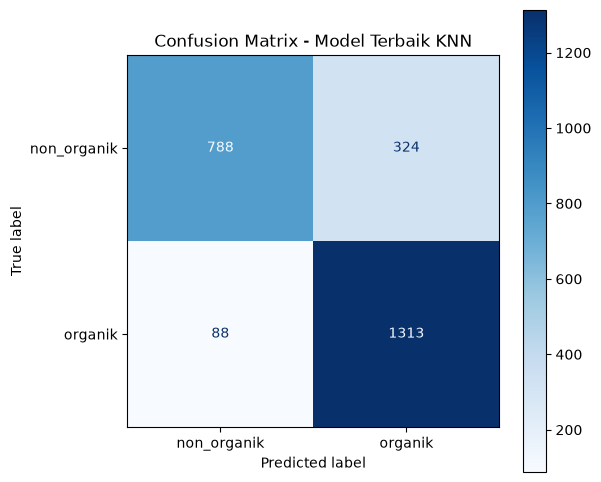

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test_enc, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix - Model Terbaik KNN")
plt.show()
